In [96]:
import torch
import torch.nn as nn
import numpy as np
from pandas import read_csv
import seaborn as sns
import matplotlib.pyplot as plt

# Read Data

In [97]:
df = read_csv('train.csv')
df = df.dropna()
a = df.to_numpy()

# Plot Data

[Text(0.5, 0, 'train_x'), Text(0, 0.5, 'train_y')]

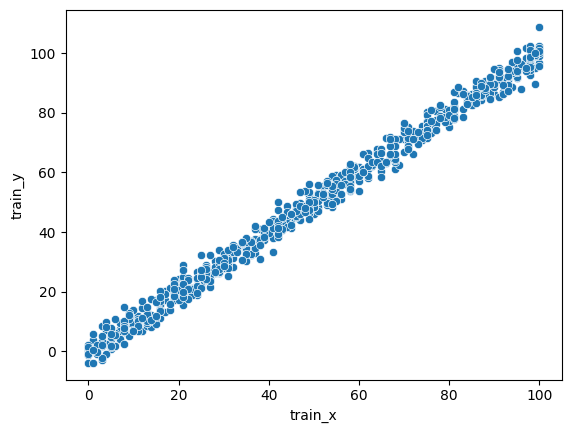

In [98]:
ax = sns.scatterplot(x=a[:, 0], y=a[:, 1])
ax.set(xlabel='train_x', ylabel='train_y')

# Transform data from numpy to torch.tensor

In [99]:
x = torch.tensor(a[:, 0], dtype = torch.float)
y = torch.tensor(a[:, 1], dtype = torch.float)

w = torch.tensor(0.0, dtype = torch.float, requires_grad = True)
b = torch.tensor(0.0, dtype = torch.float, requires_grad = True)

# Loss and Forward funtion

In [100]:
def MSELoss(y, y_pred):
    return ((y - y_pred)**2).mean()

In [101]:
def forward(x_values):
    return w * x_values + b

# Regression

In [102]:
EPOCHS = 20000
LR = 0.0001

In [103]:
for epoch in range(EPOCHS):

    # forward pass
    y_pred = forward(x)
    
    # loss
    loss = MSELoss(y, y_pred)

    # backward pass
    loss.backward()

    # update weights
    with torch.no_grad():
        w -= LR * w.grad
        b -= LR * b.grad

    # zero grads
    w.grad.zero_()
    
    if (epoch+1) % 2000 == 0:
        print(f"Epoch: {epoch+1:5.0f}, Loss: {loss.item():5.15f}")

Epoch:  2000, Loss: 8.582548141479492
Epoch:  4000, Loss: 7.871799468994141
Epoch:  6000, Loss: 8.156193733215332
Epoch:  8000, Loss: 7.871688365936279
Epoch: 10000, Loss: 7.983503341674805
Epoch: 12000, Loss: 7.870685100555420
Epoch: 14000, Loss: 7.913942337036133
Epoch: 16000, Loss: 7.869645595550537
Epoch: 18000, Loss: 7.886078834533691
Epoch: 20000, Loss: 7.868868827819824


# Prediction on Single Data

In [104]:
(float(forward(212)))

212.17288208007812

# Prediction on train data set

In [105]:
xa = np.array(x)
ya = np.array(y)

with torch.no_grad():
    ya_pred = forward(xa)

l = ((ya_pred - ya)**2).mean()
print(f"Loss on train dataset: {l}")

Loss on train dataset: 7.868919849395752


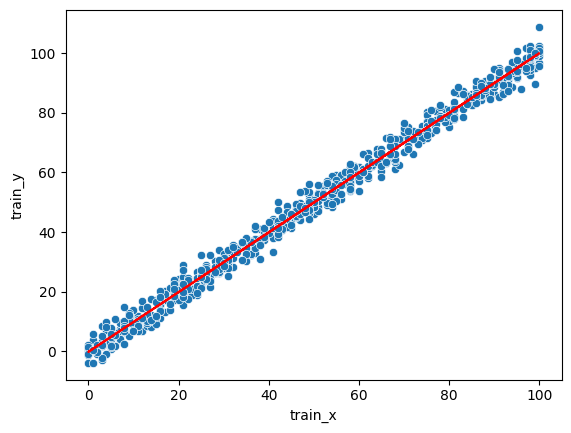

In [106]:
ax = sns.scatterplot(x=xb, y=yb)
ax.set(xlabel='train_x', ylabel='train_y')
plt.plot(xb, yb_pred, color='r')
plt.show()

# Prediction on test data set

In [107]:
df_test = read_csv('test.csv')
df_test = df_test.dropna()

x_test = df_test.iloc[:, 0].to_numpy()
y_test = df_test.iloc[:, 1].to_numpy()

with torch.no_grad():
    y_test_pred = forward(x_test)

l_test = ((y_test_pred - y_test)**2).mean()
print(f"Loss on train dataset: {l_test}")

Loss on train dataset: 9.424401822596998


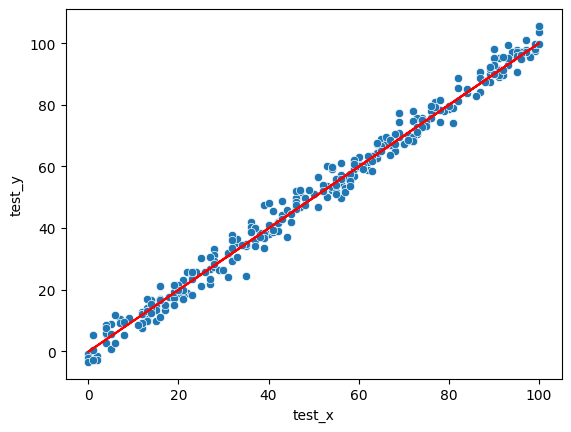

In [108]:
ax = sns.scatterplot(x=x_test, y=y_test)
ax.set(xlabel='test_x', ylabel='test_y')
plt.plot(xb, yb_pred, color='r')
plt.show()